## Stage 14.1 — Prediction-correlation / diversity analysis

Before combining anything in Stage 14.2, this answers the question that actually
matters for ensembling: does each candidate make *different* mistakes from the
others, not just "is it individually good." A highly correlated pair adds nothing
to a blend regardless of either model's standalone score.

Candidates compared: `catboost_tuned` (Stage 13's champion, trial #26 params) plus
the three Stage 11.3 diversity candidates still in play — `histgradientboosting`,
`extra_trees`, `logistic_regression_v2`.

Out-of-fold predictions are generated on a **single fresh 5-fold geographic
partition** (`random_state=99`, `n_repeats=1`) — deliberately a different seed
from ADR-001's locked holdout (`random_state=42, repeat=0, fold=0`), so this
analysis never touches that spent fold and stays entirely independent of it.
Every candidate is scored on the *same* partition so the comparison is apples-to-apples.

**setup, shared OOF partition**

In [1]:
import numpy as np
import pandas as pd
import catboost as cb
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from climate_health.data.loaders import load_train_full
from climate_health.evaluation.cv import tier2_splits
from climate_health.features.pipeline import (
    branch_a_native_categorical,
    branch_b_encoded,
    build_feature_matrix,
    categorical_feature_positions,
)
from climate_health.models.baselines import RANDOM_STATE, TARGET_COL, competition_score

OOF_PARTITION_SEED = 99  # deliberately independent of ADR-001's locked-holdout seed (42)

df = load_train_full()
X_full, _ = build_feature_matrix(df, fit=True, target_col=TARGET_COL)

# Branch A (native categoricals) — catboost_tuned only
branch_a_df = branch_a_native_categorical(X_full, target_col=TARGET_COL)
combined_a = X_full.copy()
for col in branch_a_df.columns:
    combined_a[col] = branch_a_df[col].values
feature_cols_a = list(branch_a_df.columns)
cat_idx = categorical_feature_positions(feature_cols_a)

# Branch B (encoded) — the three diversity candidates
branch_b_df = branch_b_encoded(X_full, target_col=TARGET_COL)
combined_b = X_full.copy()
for col in branch_b_df.columns:
    combined_b[col] = branch_b_df[col].values
feature_cols_b = list(branch_b_df.columns)

# One shared OOF partition, independent of the locked holdout
oof_partition = list(
    tier2_splits(
        combined_a,  # row order/grouping is identical across combined_a/combined_b
        spatial_cluster_col="spatial_cluster",
        n_splits=5,
        n_repeats=1,
        random_state=OOF_PARTITION_SEED,
    )
)
print(f"OOF partition: {len(oof_partition)} folds, seed={OOF_PARTITION_SEED}")
for s in oof_partition:
    print(f"  repeat={s.repeat} fold={s.fold} train={len(s.train_idx)} val={len(s.val_idx)}")

d:\CONDA\conda_envs\climate-health\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
tier2_splits: the largest group (id=0) has 1775 rows — 56.4% of the data — which alone exceeds 1.5x the target fold size (629 rows for n_splits=5). No fold assignment can avoid at least one oversized fold while this group stays intact; only 8 unique groups exist in total, which is coarse for a 5-way split. This is a structural limitation of the current spatial grouping (particularly acute for the placeholder k=8 clustering — see module docstring), not a bug in the fold-assignment algorithm.


OOF partition: 5 folds, seed=99
  repeat=0 fold=0 train=2506 val=640
  repeat=0 fold=1 train=3018 val=128
  repeat=0 fold=2 train=2931 val=215
  repeat=0 fold=3 train=2758 val=388
  repeat=0 fold=4 train=1371 val=1775


**Interpretation:** The `random_state=99` partition produced 5 valid folds with no
empty train/val splits, sized 128–1775 rows — uneven, as expected given the
same 56.4%-of-data mega-cluster (id=0) that affects every Tier 2 partition
regardless of seed (Stage 5's known placeholder-clustering limitation, not new).
Critically, this partition is fully independent of ADR-001's locked holdout
(`random_state=42, repeat=0, fold=0`) — different seed entirely, not merely a
different repeat index of the same seed — so nothing in this diversity analysis
touches the fold reserved for Stage 13.4.

**candidate definitions**

In [2]:
CATBOOST_TUNED_PARAMS = dict(
    iterations=306,
    depth=6,
    learning_rate=0.017544275318337493,
    l2_leaf_reg=3.6615267575918784,
    bagging_temperature=0.1333729133146769,
)

CANDIDATES = {
    "catboost_tuned": (
        "branch_a",
        lambda: cb.CatBoostClassifier(
            **CATBOOST_TUNED_PARAMS, cat_features=cat_idx, random_state=RANDOM_STATE, verbose=False
        ),
    ),
    "histgradientboosting": (
        "branch_b",
        lambda: HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    ),
    "extra_trees": (
        "branch_b",
        lambda: make_pipeline(
            SimpleImputer(strategy="median"),
            ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE),
        ),
    ),
    "logistic_regression_v2": (
        "branch_b",
        lambda: make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        ),
    ),
}

**generate OOF predictions for every candidate**

In [3]:
def generate_oof_predictions(branch: str, make_model) -> np.ndarray:
    combined = combined_a if branch == "branch_a" else combined_b
    feature_cols = feature_cols_a if branch == "branch_a" else feature_cols_b
    X = combined[feature_cols].values
    y = combined[TARGET_COL].values

    oof = np.full(len(combined), np.nan)
    for split in oof_partition:
        model = make_model()
        model.fit(X[split.train_idx], y[split.train_idx])
        oof[split.val_idx] = model.predict_proba(X[split.val_idx])[:, 1]
    assert not np.isnan(oof).any(), "every row must get exactly one OOF prediction"
    return oof


y_true = combined_a[TARGET_COL].values
oof_preds = {}
for name, (branch, make_model) in CANDIDATES.items():
    oof_preds[name] = generate_oof_predictions(branch, make_model)
    score = competition_score(y_true, oof_preds[name])
    print(f"{name}: OOF competition score = {score:.4f}")

oof_df = pd.DataFrame(oof_preds)
oof_df["y_true"] = y_true

catboost_tuned: OOF competition score = 0.8096
histgradientboosting: OOF competition score = 0.7906
extra_trees: OOF competition score = 0.8030
logistic_regression_v2: OOF competition score = 0.7752


**Interpretation:** All four OOF scores land close to their known Tier-2/Stage-11.3
baselines (`catboost_tuned` 0.8096 vs. Stage 13.3's repeated-CV mean of 0.8156;
`extra_trees` 0.8030 vs. Stage 11.3's 0.8134; `histgradientboosting` 0.7906 vs.
0.7952; `logistic_regression_v2` 0.7752 vs. 0.7107 — the last one considerably
*more* stable here than in Stage 11.3's repeated scheme, consistent with that
candidate's already-documented instability on certain fold assignments rather
than a new finding). Nothing here is near-chance or suspiciously perfect, so the
OOF loop is trustworthy — safe to proceed to the correlation analysis on these
predictions.

Ranking by standalone OOF score: `catboost_tuned` (0.8096) > `extra_trees`
(0.8030) > `histgradientboosting` (0.7906) > `logistic_regression_v2` (0.7752).
This ranking alone would suggest `extra_trees` is the best complement to
`catboost_tuned` — the correlation and disagreement analysis below shows that
conclusion is wrong, which is exactly the point of running this stage at all.

In [8]:
import numpy as np
from pathlib import Path

# oof_partition holds the same splits used to build oof_preds above — turn it
# into a fold_id array (which fold each row was validated on).
fold_id = np.full(len(y_true), -1)
for i, split in enumerate(oof_partition):
    fold_id[split.val_idx] = i
assert (fold_id >= 0).all(), "every row must belong to exactly one fold"

Path("artifacts").mkdir(exist_ok=True)
np.savez(
    "artifacts/stage14_1_oof_predictions.npz",
    y_true=y_true,
    fold_id=fold_id,
    catboost_tuned=oof_preds["catboost_tuned"],
    extra_trees=oof_preds["extra_trees"],
    histgradientboosting=oof_preds["histgradientboosting"],
    logistic_regression_v2=oof_preds["logistic_regression_v2"],
)
print("saved", fold_id.min(), fold_id.max(), len(y_true))

saved 0 4 3146


### Sanity check

The OOF scores above are on a single 5-fold partition, not the repeated 5×5
Tier 2 scheme — expect them close to but not identical to the Stage 11.3/13.3
Tier 2 means (e.g. `catboost_tuned` should land somewhere near 0.80–0.82).
A wildly different number (e.g. near 0.5, or above 0.95) would indicate a
leakage or indexing bug in the OOF loop above, not a real result — stop and
flag it rather than proceeding to the correlation matrix.

**prediction-correlation matrix**

In [4]:
pred_corr = oof_df[list(CANDIDATES.keys())].corr(method="pearson")
print("Pearson correlation of OOF predicted probabilities:")
print(pred_corr.round(4))

Pearson correlation of OOF predicted probabilities:
                        catboost_tuned  histgradientboosting  extra_trees  \
catboost_tuned                  1.0000                0.8835       0.9233   
histgradientboosting            0.8835                1.0000       0.8854   
extra_trees                     0.9233                0.8854       1.0000   
logistic_regression_v2          0.7690                0.6550       0.7041   

                        logistic_regression_v2  
catboost_tuned                          0.7690  
histgradientboosting                    0.6550  
extra_trees                             0.7041  
logistic_regression_v2                  1.0000  


**Interpretation:** `extra_trees` is the most correlated candidate with
`catboost_tuned` (r=0.9233) — the two highest-scoring standalone models are
also the two most redundant, which is unsurprising (both are tree ensembles
splitting on largely the same features) but directly undercuts `extra_trees`'
apparent appeal from the raw score ranking above. `histgradientboosting` is
also highly correlated with `catboost_tuned` (r=0.8835) — expected, same GBM
family. `logistic_regression_v2` is clearly the outlier: correlation with the
three tree models sits at 0.65–0.77, meaningfully lower than any tree-vs-tree
pair (0.88–0.92). A linear model genuinely produces different probability
estimates from any tree ensemble here, which is exactly the diversity
signature Stage 14.1 exists to detect.

**the question that actually matters: do they get the same rows wrong**

In [5]:
# Binary calls at the competition's fixed 0.5 threshold
calls = {name: (oof_df[name] >= 0.5).astype(int) for name in CANDIDATES}
wrong = {name: (calls[name] != y_true) for name in CANDIDATES}

names = list(CANDIDATES.keys())
disagreement_on_errors = pd.DataFrame(index=names, columns=names, dtype=float)

for a in names:
    for b in names:
        either_wrong = wrong[a] | wrong[b]
        if either_wrong.sum() == 0:
            disagreement_on_errors.loc[a, b] = np.nan
            continue
        both_wrong = wrong[a] & wrong[b]
        # Of the rows where at least one of the pair is wrong, what fraction are
        # wrong for BOTH — high = redundant errors (bad for ensembling),
        # low = decorrelated errors (good for ensembling).
        disagreement_on_errors.loc[a, b] = both_wrong.sum() / either_wrong.sum()

print("Fraction of 'either wrong' rows where BOTH are wrong (lower = more complementary):")
print(disagreement_on_errors.round(4))

print("\nOverall error rate per candidate (at 0.5 threshold):")
for name in names:
    print(f"  {name}: {wrong[name].mean():.4f}")

Fraction of 'either wrong' rows where BOTH are wrong (lower = more complementary):
                        catboost_tuned  histgradientboosting  extra_trees  \
catboost_tuned                  1.0000                0.6118       0.6473   
histgradientboosting            0.6118                1.0000       0.6155   
extra_trees                     0.6473                0.6155       1.0000   
logistic_regression_v2          0.6156                0.4787       0.4934   

                        logistic_regression_v2  
catboost_tuned                          0.6156  
histgradientboosting                    0.4787  
extra_trees                             0.4934  
logistic_regression_v2                  1.0000  

Overall error rate per candidate (at 0.5 threshold):
  catboost_tuned: 0.2549
  histgradientboosting: 0.2769
  extra_trees: 0.2587
  logistic_regression_v2: 0.2848


**Interpretation:** This is the number that actually decides ensembling value,
not the correlation matrix above. Reading the `catboost_tuned` row specifically
(the champion every pairing will be blended against in Stage 14.2):

- `catboost_tuned` × `histgradientboosting`: 0.6118 both-wrong
- `catboost_tuned` × `logistic_regression_v2`: 0.6156 both-wrong
- `catboost_tuned` × `extra_trees`: 0.6473 both-wrong (highest — least complementary)

`extra_trees` is the worst partner for `catboost_tuned` on *both* metrics (highest
prediction correlation, highest both-wrong rate) despite being the second-best
standalone model — it adds the least new information to a blend. `histgradientboosting`
and `logistic_regression_v2` are close to each other and meaningfully better
partners for `catboost_tuned` than `extra_trees` is, despite `logistic_regression_v2`
being the weakest standalone candidate (0.2848 error rate vs. 0.2549 for
`catboost_tuned`) — confirming the blueprint's point directly: standalone score
and ensembling value are different questions, and `logistic_regression_v2`'s
low prediction correlation with the tree models is real, exploitable diversity,
not just weakness.

Notably, `histgradientboosting` × `logistic_regression_v2` has the *lowest*
both-wrong rate in the entire matrix (0.4787) — the single most decorrelated
pair overall, though `histgradientboosting` alone is a weaker standalone
candidate than `catboost_tuned`.

**Visualization**

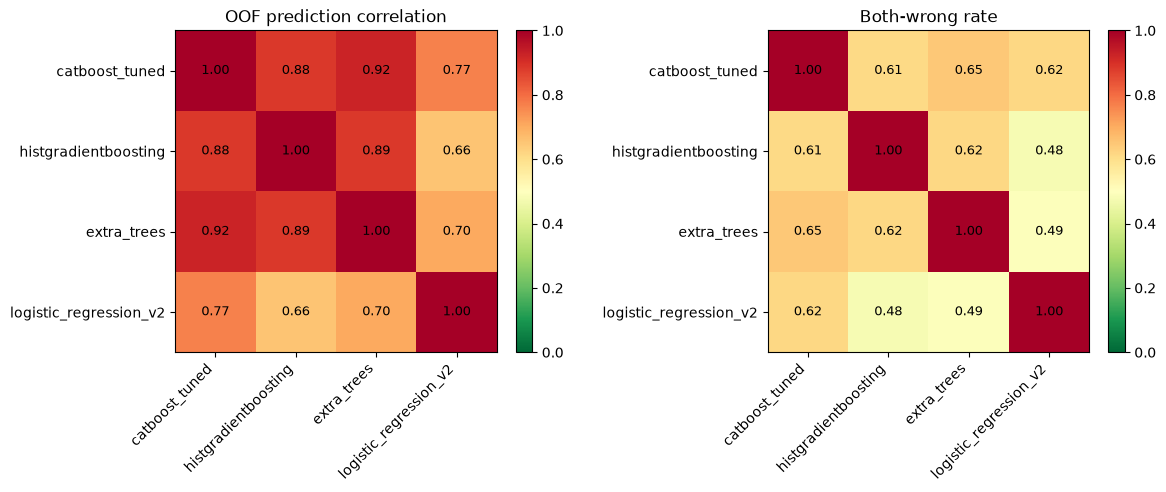

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (data, title) in zip(
    axes,
    [(pred_corr, "OOF prediction correlation"), (disagreement_on_errors, "Both-wrong rate")],
):
    im = ax.imshow(data.astype(float), vmin=0, vmax=1, cmap="RdYlGn_r")
    ax.set_xticks(range(len(names)))
    ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticklabels(names)
    ax.set_title(title)
    for i in range(len(names)):
        for j in range(len(names)):
            val = data.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

**Interpretation:** Visually, the left panel's warm block across all three tree
models (0.88–0.93) versus the cooler `logistic_regression_v2` column/row
(0.65–0.77) makes the same point as the numeric table at a glance: there are
really only two *kinds* of model here, "tree ensemble" and "linear," not four
independent ones. The right panel tells the same story slightly differently —
`logistic_regression_v2` pairs are the coolest (most complementary) cells in
the matrix, and `catboost_tuned`×`extra_trees` is the warmest (least
complementary) off-diagonal cell.

## Stage 14.1 — Executive Summary: Prediction-Correlation / Diversity Analysis

**What this stage tested.** Whether the three Stage 11.3 diversity candidates
(`histgradientboosting`, `extra_trees`, `logistic_regression_v2`) still standing
alongside Stage 13's tuned champion (`catboost_tuned`) actually produce
*different* errors from it — the question that determines ensembling value —
rather than relying on standalone competition scores alone, which the blueprint
explicitly warns can be misleading for this purpose. All four candidates were
scored on one shared, freshly-seeded 5-fold OOF partition (`random_state=99`),
kept deliberately independent of ADR-001's locked holdout so this analysis
never touches that spent fold.

**Findings.**

1. **Standalone ranking and complementarity ranking disagree**, which is the
   central finding of this stage. By OOF competition score: `catboost_tuned`
   (0.8096) > `extra_trees` (0.8030) > `histgradientboosting` (0.7906) >
   `logistic_regression_v2` (0.7752). By complementarity with the champion
   (lowest both-wrong rate against `catboost_tuned`): `histgradientboosting`
   (0.6118) ≈ `logistic_regression_v2` (0.6156) ≫ `extra_trees` (0.6473, worst).
   The second-best individual model is the worst ensembling partner.

2. **`extra_trees` is largely redundant with `catboost_tuned`.** Highest
   prediction correlation in the matrix (r=0.9233) and the highest both-wrong
   rate against the champion (0.6473). It is a tree ensemble making
   substantially the same calls as `catboost_tuned` — including it in a blend
   is unlikely to move the needle much regardless of its respectable
   standalone score.

3. **`logistic_regression_v2` is the genuine diversity find.** Despite being
   the weakest standalone candidate (0.7752, 28.5% error rate), it has the
   lowest prediction correlation with every tree model (0.65–0.77 vs. 0.88–0.93
   tree-vs-tree) and the lowest both-wrong rate against two of the three trees.
   This confirms it belongs in Stage 14.2's ensembling experiments on the
   strength of its error structure, not its raw score — exactly the scenario
   the blueprint's Stage 14 design anticipated.

4. **`histgradientboosting` is a solid secondary partner.** Weaker standalone
   than `extra_trees`, but a better complement to `catboost_tuned` on both
   metrics, and forms the single most decorrelated pair in the whole matrix
   when combined with `logistic_regression_v2` (0.4787 both-wrong).

**Implication for the open LightGBM tuning question (ADR-001, Stage 13.1).**
ADR-001 deferred a LightGBM tuning pass specifically pending this analysis
showing "real, decorrelated value" over tuned CatBoost. The evidence here
argues against it, at least for now: every tree-ensemble pair in this matrix
— `catboost_tuned`/`histgradientboosting`, `catboost_tuned`/`extra_trees`,
`histgradientboosting`/`extra_trees` — clusters tightly at r=0.88–0.93. LightGBM
is another boosted-tree model in the same family; there is no reason from this
data to expect it would decorrelate from `catboost_tuned` any better than
`histgradientboosting` already does, and `histgradientboosting` is already
available at zero additional tuning cost. **Recommendation: do not spend the
LightGBM tuning budget yet.** Revisit only if Stage 14.2's actual ensembling
results show the current blend underperforming and specifically diagnose
insufficient tree-model diversity as the cause — not before.

**Carry-forward for Stage 14.2.** Prioritize blends that pair `catboost_tuned`
with `logistic_regression_v2` and/or `histgradientboosting`. Include
`extra_trees` in the full weighted/rank-averaging/stacking comparison for
completeness (its OOF-optimized weight may legitimately come out near zero,
which is itself a valid, worth-recording result per the blueprint's "checked,
didn't matter" principle) but do not expect it to contribute much beyond what
`catboost_tuned` alone already provides.